# 06 — AI Research Agent: Tool-Using Autonomous Dossier Generator

**AI Equity Research Lab** — FGV EAESP (Aula 7)

This notebook demonstrates a **tool-using AI agent** that:
1. Calls 6 specialised data tools to gather KPIs, prices, macro, sentiment, valuation, and scores
2. Detects risk flags and opportunities automatically
3. Computes a profile-adjusted investment score
4. Generates a complete investment dossier

The agent is fully autonomous: given a list of tickers and an investor profile, it produces a ready-to-read report without human intervention.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\João Paulo\equity_research


---
## 1. Tool Demonstrations

The agent has 6 tools at its disposal.  Each is a plain Python function that reads from processed parquet files and returns a dictionary.

| # | Tool | Data Source | Returns |
|---|------|------------|----------|
| 1 | `get_kpis` | kpis_wide | 14 financial KPIs for ticker/year |
| 2 | `get_price_history` | prices_daily | Price stats, volatility, momentum |
| 3 | `get_macro_snapshot` | macro_monthly + BCB API | Selic, IPCA, USD/BRL |
| 4 | `get_sentiment` | sentiment_scores + textual_index | NLP signals |
| 5 | `get_valuation` | multiples + scenarios + ultimate | Multiples, upside, rec |
| 6 | `get_full_score` | ultimate + clusters + supervised | Complete score breakdown |

In [2]:
from src.agent.tools import (
    get_kpis, get_price_history, get_macro_snapshot,
    get_sentiment, get_valuation, get_full_score,
)

# Tool 1 — KPIs
print("=== Tool 1: get_kpis('ITUB4', 2024) ===")
kpis = get_kpis('ITUB4', 2024)
for k, v in kpis.items():
    if k not in ('ticker', 'sector', 'year'):
        print(f"  {k:25s} = {v}")

=== Tool 1: get_kpis('ITUB4', 2024) ===
  net_margin                = nan
  roe                       = nan
  roa                       = nan
  ebit_margin               = 0.14181935299169768
  debt_to_equity            = nan
  net_debt_to_ebit          = nan
  current_ratio             = nan
  cash_to_revenue           = 0.10773630594522378
  revenue_cagr              = 0.17864190357041276
  net_income_cagr           = nan
  volatility_annualized     = 0.18353506380283424
  max_drawdown              = -0.1647726243738431
  momentum_6m               = -0.040547703658446954
  momentum_12m              = -0.029347745805698877


In [3]:
# Tool 2 — Price History
print("=== Tool 2: get_price_history('EGIE3') ===")
price = get_price_history('EGIE3')
for k, v in price.items():
    print(f"  {k:25s} = {v}")

=== Tool 2: get_price_history('EGIE3') ===
  current_price             = 31.37
  price_52w_high            = 34.01
  price_52w_low             = 23.63
  volatility_annualized     = 0.2284
  momentum_12m              = 0.3168
  max_drawdown              = -0.1968


In [4]:
# Tool 3 — Macro Snapshot
print("=== Tool 3: get_macro_snapshot() ===")
macro = get_macro_snapshot()
for k, v in macro.items():
    print(f"  {k:25s} = {v}")

=== Tool 3: get_macro_snapshot() ===


  selic_current             = 0.1475
  ipca_last_12m             = 4.19
  usdbrl_current            = 5.5024


In [5]:
# Tool 4 — Sentiment
print("=== Tool 4: get_sentiment('CMIG4') ===")
sent = get_sentiment('CMIG4')
for k, v in sent.items():
    print(f"  {k:25s} = {v}")

=== Tool 4: get_sentiment('CMIG4') ===
  textual_index             = 87.5
  sentiment_label           = Positive
  top_positive_keywords     = ['dividendo', 'lucro']
  top_negative_keywords     = []
  text_count                = 30


In [6]:
# Tool 5 — Valuation
print("=== Tool 5: get_valuation('BBAS3') ===")
val = get_valuation('BBAS3')
for k, v in val.items():
    print(f"  {k:25s} = {v}")

=== Tool 5: get_valuation('BBAS3') ===
  pl                        = 2.24
  pvp                       = 0.38
  ev_ebitda                 = None
  discount_premium_pl       = -0.57
  bull_upside               = 0.11
  base_upside               = 0.04
  bear_upside               = -0.036
  recommendation            = Hold
  ultimate_score            = 63.7


In [7]:
# Tool 6 — Full Score
print("=== Tool 6: get_full_score('CPFE3') ===")
score = get_full_score('CPFE3')
for k, v in score.items():
    print(f"  {k:25s} = {v}")

=== Tool 6: get_full_score('CPFE3') ===
  fundamental_score         = 58.0
  textual_index             = 94.1
  valuation_score           = 38.0
  ultimate_score            = 65.7
  recommendation            = Buy
  rank_overall              = 4
  cluster_label             = Risk
  outperform_probability    = 0.994


---
## 2. Agent Run — 3-Ticker Dossier

The `EquityResearchAgent` orchestrates the 6 tools in sequence for each ticker, detects risk flags, computes a profile-adjusted score, and produces a formatted dossier.

In [8]:
from src.agent.agent import EquityResearchAgent

agent = EquityResearchAgent(profile="base")
dossier = agent.generate_dossier(["ITUB4", "EGIE3", "CMIG4"])
print(dossier)

[13:00:59] Agent started | profile=base | tickers=['ITUB4', 'EGIE3', 'CMIG4']
[13:00:59] Calling get_macro_snapshot()...



[13:01:00] Analyzing ITUB4 — Itaú Unibanco
[13:01:00] Calling get_kpis(ITUB4, 2024)...
[13:01:00] Calling get_price_history(ITUB4)...
[13:01:00] Calling get_sentiment(ITUB4)...
[13:01:00] Calling get_valuation(ITUB4)...
[13:01:00] Calling get_full_score(ITUB4)...

[13:01:00] Analyzing EGIE3 — Engie Brasil
[13:01:00] Calling get_kpis(EGIE3, 2024)...
[13:01:00] Calling get_price_history(EGIE3)...
[13:01:00] Calling get_sentiment(EGIE3)...
[13:01:00] Calling get_valuation(EGIE3)...
[13:01:00] Calling get_full_score(EGIE3)...

[13:01:00] Analyzing CMIG4 — Cemig
[13:01:00] Calling get_kpis(CMIG4, 2024)...
[13:01:00] Calling get_price_history(CMIG4)...
[13:01:00] Calling get_sentiment(CMIG4)...
[13:01:00] Calling get_valuation(CMIG4)...
[13:01:00] Calling get_full_score(CMIG4)...

[13:01:00] Agent finished — 3 tickers analysed

[13:01:00] Dossier saved to C:\Users\João Paulo\equity_research\data\output\dossier_2026-03-27_base.txt
  EQUITY RESEARCH DOSSIER -- 2026-03-27
  Profile: base | Gen

---
## 3. Profile Comparison — Conservative vs Base vs Aggressive

The same set of tickers can yield different recommendations depending on the investor profile:

| Profile | Emphasis |
|---------|----------|
| **Conservative** | Valuation (35%) + Fundamentals (30%) + Sentiment (25%) |
| **Base** | Fundamentals (35%) + Valuation (25%) + Sentiment (25%) |
| **Aggressive** | ML Outperform (35%) + Fundamentals (30%) + Valuation (20%) |

In [9]:
from src.agent.company_names import COMPANY_NAMES

all_tickers = list(COMPANY_NAMES.keys())
profiles = ["conservative", "base", "aggressive"]
results = {}

for p in profiles:
    a = EquityResearchAgent(profile=p)
    r = a.analyze(all_tickers)
    results[p] = r

[13:01:00] Agent started | profile=conservative | tickers=['ITUB4', 'BBDC4', 'BBAS3', 'SANB11', 'ABCB4', 'EGIE3', 'EQTL3', 'CPFE3', 'TAEE11', 'CMIG4']
[13:01:00] Calling get_macro_snapshot()...



[13:01:01] Analyzing ITUB4 — Itaú Unibanco
[13:01:01] Calling get_kpis(ITUB4, 2024)...
[13:01:01] Calling get_price_history(ITUB4)...
[13:01:01] Calling get_sentiment(ITUB4)...
[13:01:01] Calling get_valuation(ITUB4)...
[13:01:01] Calling get_full_score(ITUB4)...

[13:01:01] Analyzing BBDC4 — Bradesco
[13:01:01] Calling get_kpis(BBDC4, 2024)...
[13:01:01] Calling get_price_history(BBDC4)...
[13:01:01] Calling get_sentiment(BBDC4)...
[13:01:01] Calling get_valuation(BBDC4)...
[13:01:01] Calling get_full_score(BBDC4)...

[13:01:01] Analyzing BBAS3 — Banco do Brasil
[13:01:01] Calling get_kpis(BBAS3, 2024)...
[13:01:01] Calling get_price_history(BBAS3)...
[13:01:01] Calling get_sentiment(BBAS3)...
[13:01:01] Calling get_valuation(BBAS3)...
[13:01:01] Calling get_full_score(BBAS3)...

[13:01:01] Analyzing SANB11 — Santander Brasil
[13:01:01] Calling get_kpis(SANB11, 2024)...
[13:01:01] Calling get_price_history(SANB11)...
[13:01:01] Calling get_sentiment(SANB11)...
[13:01:01] Calling get_

[13:01:01] Calling get_valuation(ABCB4)...
[13:01:01] Calling get_full_score(ABCB4)...

[13:01:02] Analyzing EGIE3 — Engie Brasil
[13:01:02] Calling get_kpis(EGIE3, 2024)...
[13:01:02] Calling get_price_history(EGIE3)...
[13:01:02] Calling get_sentiment(EGIE3)...
[13:01:02] Calling get_valuation(EGIE3)...
[13:01:02] Calling get_full_score(EGIE3)...

[13:01:02] Analyzing EQTL3 — Equatorial Energia
[13:01:02] Calling get_kpis(EQTL3, 2024)...
[13:01:02] Calling get_price_history(EQTL3)...
[13:01:02] Calling get_sentiment(EQTL3)...
[13:01:02] Calling get_valuation(EQTL3)...
[13:01:02] Calling get_full_score(EQTL3)...

[13:01:02] Analyzing CPFE3 — CPFL Energia
[13:01:02] Calling get_kpis(CPFE3, 2024)...
[13:01:02] Calling get_price_history(CPFE3)...
[13:01:02] Calling get_sentiment(CPFE3)...
[13:01:02] Calling get_valuation(CPFE3)...
[13:01:02] Calling get_full_score(CPFE3)...

[13:01:02] Analyzing TAEE11 — Taesa
[13:01:02] Calling get_kpis(TAEE11, 2024)...
[13:01:02] Calling get_price_hist

[13:01:02] Calling get_full_score(TAEE11)...

[13:01:02] Analyzing CMIG4 — Cemig
[13:01:02] Calling get_kpis(CMIG4, 2024)...
[13:01:02] Calling get_price_history(CMIG4)...
[13:01:02] Calling get_sentiment(CMIG4)...
[13:01:02] Calling get_valuation(CMIG4)...
[13:01:02] Calling get_full_score(CMIG4)...

[13:01:02] Agent finished — 10 tickers analysed
[13:01:02] Agent started | profile=base | tickers=['ITUB4', 'BBDC4', 'BBAS3', 'SANB11', 'ABCB4', 'EGIE3', 'EQTL3', 'CPFE3', 'TAEE11', 'CMIG4']
[13:01:02] Calling get_macro_snapshot()...



[13:01:02] Analyzing ITUB4 — Itaú Unibanco
[13:01:02] Calling get_kpis(ITUB4, 2024)...
[13:01:02] Calling get_price_history(ITUB4)...
[13:01:02] Calling get_sentiment(ITUB4)...
[13:01:02] Calling get_valuation(ITUB4)...
[13:01:02] Calling get_full_score(ITUB4)...

[13:01:02] Analyzing BBDC4 — Bradesco
[13:01:02] Calling get_kpis(BBDC4, 2024)...
[13:01:02] Calling get_price_history(BBDC4)...
[13:01:02] Calling get_sentiment(BBDC4)...
[13:01:02] Calling get_valuation(BBDC4)...
[13:01:02] Calling get_full_score(BBDC4)...

[13:01:02] Analyzing BBAS3 — Banco do Brasil
[13:01:02] Calling get_kpis(BBAS3, 2024)...
[13:01:02] Calling get_price_history(BBAS3)...
[13:01:02] Calling get_sentiment(BBAS3)...
[13:01:02] Calling get_valuation(BBAS3)...
[13:01:02] Calling get_full_score(BBAS3)...

[13:01:02] Analyzing SANB11 — Santander Brasil
[13:01:02] Calling get_kpis(SANB11, 2024)...
[13:01:02] Calling get_price_history(SANB11)...
[13:01:02] Calling get_sentiment(SANB11)...
[13:01:02] Calling get_


[13:01:03] Analyzing EGIE3 — Engie Brasil
[13:01:03] Calling get_kpis(EGIE3, 2024)...
[13:01:03] Calling get_price_history(EGIE3)...
[13:01:03] Calling get_sentiment(EGIE3)...
[13:01:03] Calling get_valuation(EGIE3)...
[13:01:03] Calling get_full_score(EGIE3)...

[13:01:03] Analyzing EQTL3 — Equatorial Energia
[13:01:03] Calling get_kpis(EQTL3, 2024)...
[13:01:03] Calling get_price_history(EQTL3)...
[13:01:03] Calling get_sentiment(EQTL3)...
[13:01:03] Calling get_valuation(EQTL3)...
[13:01:03] Calling get_full_score(EQTL3)...

[13:01:03] Analyzing CPFE3 — CPFL Energia
[13:01:03] Calling get_kpis(CPFE3, 2024)...
[13:01:03] Calling get_price_history(CPFE3)...
[13:01:03] Calling get_sentiment(CPFE3)...
[13:01:03] Calling get_valuation(CPFE3)...
[13:01:03] Calling get_full_score(CPFE3)...

[13:01:03] Analyzing TAEE11 — Taesa
[13:01:03] Calling get_kpis(TAEE11, 2024)...
[13:01:03] Calling get_price_history(TAEE11)...
[13:01:03] Calling get_sentiment(TAEE11)...
[13:01:03] Calling get_valua


[13:01:03] Agent finished — 10 tickers analysed
[13:01:03] Agent started | profile=aggressive | tickers=['ITUB4', 'BBDC4', 'BBAS3', 'SANB11', 'ABCB4', 'EGIE3', 'EQTL3', 'CPFE3', 'TAEE11', 'CMIG4']
[13:01:03] Calling get_macro_snapshot()...



[13:01:03] Analyzing ITUB4 — Itaú Unibanco
[13:01:03] Calling get_kpis(ITUB4, 2024)...
[13:01:03] Calling get_price_history(ITUB4)...
[13:01:03] Calling get_sentiment(ITUB4)...
[13:01:03] Calling get_valuation(ITUB4)...
[13:01:03] Calling get_full_score(ITUB4)...

[13:01:03] Analyzing BBDC4 — Bradesco
[13:01:03] Calling get_kpis(BBDC4, 2024)...
[13:01:03] Calling get_price_history(BBDC4)...
[13:01:03] Calling get_sentiment(BBDC4)...
[13:01:03] Calling get_valuation(BBDC4)...
[13:01:03] Calling get_full_score(BBDC4)...

[13:01:03] Analyzing BBAS3 — Banco do Brasil
[13:01:03] Calling get_kpis(BBAS3, 2024)...
[13:01:03] Calling get_price_history(BBAS3)...
[13:01:03] Calling get_sentiment(BBAS3)...
[13:01:03] Calling get_valuation(BBAS3)...
[13:01:03] Calling get_full_score(BBAS3)...

[13:01:04] Analyzing SANB11 — Santander Brasil
[13:01:04] Calling get_kpis(SANB11, 2024)...
[13:01:04] Calling get_price_history(SANB11)...
[13:01:04] Calling get_sentiment(SANB11)...
[13:01:04] Calling get_

[13:01:04] Calling get_full_score(ABCB4)...

[13:01:04] Analyzing EGIE3 — Engie Brasil
[13:01:04] Calling get_kpis(EGIE3, 2024)...
[13:01:04] Calling get_price_history(EGIE3)...
[13:01:04] Calling get_sentiment(EGIE3)...
[13:01:04] Calling get_valuation(EGIE3)...
[13:01:04] Calling get_full_score(EGIE3)...

[13:01:04] Analyzing EQTL3 — Equatorial Energia
[13:01:04] Calling get_kpis(EQTL3, 2024)...
[13:01:04] Calling get_price_history(EQTL3)...
[13:01:04] Calling get_sentiment(EQTL3)...
[13:01:04] Calling get_valuation(EQTL3)...
[13:01:04] Calling get_full_score(EQTL3)...

[13:01:04] Analyzing CPFE3 — CPFL Energia
[13:01:04] Calling get_kpis(CPFE3, 2024)...
[13:01:04] Calling get_price_history(CPFE3)...
[13:01:04] Calling get_sentiment(CPFE3)...
[13:01:04] Calling get_valuation(CPFE3)...
[13:01:04] Calling get_full_score(CPFE3)...

[13:01:04] Analyzing TAEE11 — Taesa
[13:01:04] Calling get_kpis(TAEE11, 2024)...
[13:01:04] Calling get_price_history(TAEE11)...
[13:01:04] Calling get_senti

[13:01:04] Calling get_valuation(CMIG4)...
[13:01:04] Calling get_full_score(CMIG4)...

[13:01:04] Agent finished — 10 tickers analysed


In [10]:
# Build comparison table
rows = []
for ticker in all_tickers:
    row = {"ticker": ticker}
    for p in profiles:
        t = [x for x in results[p]["tickers"] if x["ticker"] == ticker][0]
        row[f"{p}_score"] = t["profile_score"]
        row[f"{p}_rec"] = t["profile_recommendation"]
    rows.append(row)

comp = pd.DataFrame(rows)
comp

,ticker,conservative_score,conservative_rec,base_score,base_rec,aggressive_score,aggressive_rec
0,ITUB4,79.9,Buy,79.6,Buy,82.5,Buy
1,BBDC4,58.0,Hold,53.0,Hold,38.7,Sell
2,BBAS3,63.6,Hold,61.2,Hold,60.4,Hold
3,SANB11,37.7,Sell,35.7,Sell,38.4,Sell
4,ABCB4,59.5,Hold,59.5,Hold,56.7,Hold
5,EGIE3,69.1,Buy,71.9,Buy,76.8,Buy
6,EQTL3,36.6,Sell,37.3,Sell,36.9,Sell
7,CPFE3,64.2,Hold,68.2,Buy,73.9,Buy
8,TAEE11,50.4,Hold,56.2,Hold,62.7,Hold
9,CMIG4,70.4,Buy,69.0,Buy,64.1,Hold


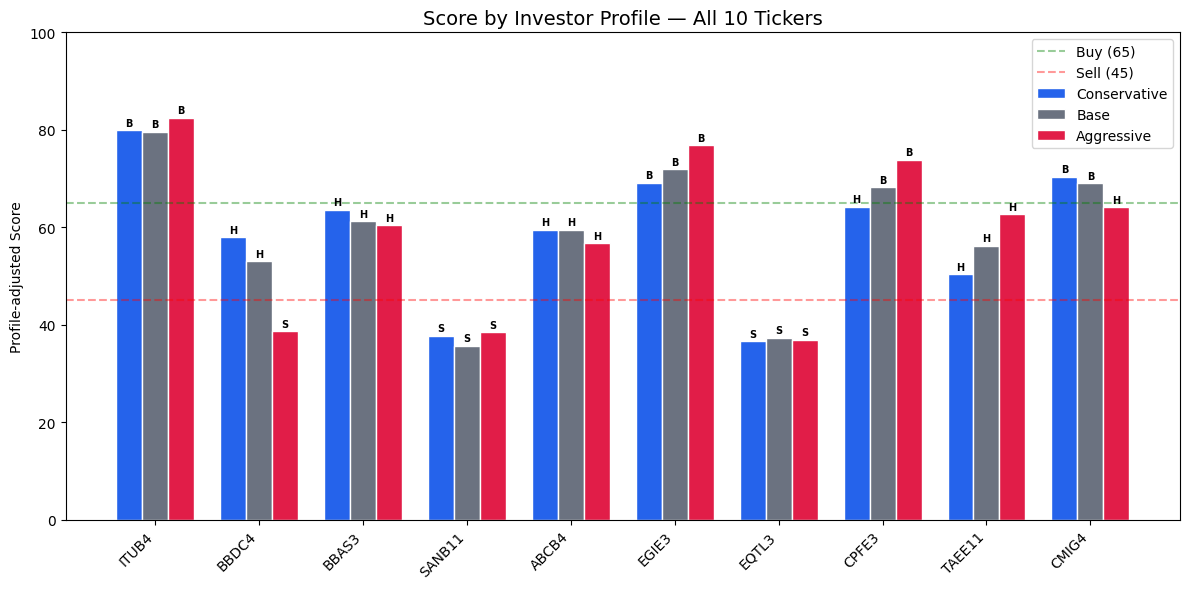

In [11]:
# Visualize profile score differences
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comp))
w = 0.25

colors = {"conservative": "#2563eb", "base": "#6b7280", "aggressive": "#e11d48"}

for i, p in enumerate(profiles):
    bars = ax.bar(x + i * w, comp[f"{p}_score"], w,
                  label=p.title(), color=colors[p], edgecolor="white")
    # Add rec label on each bar
    for bar, rec in zip(bars, comp[f"{p}_rec"]):
        label = rec[0]  # B/H/S
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                label, ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.axhline(65, color="green", linestyle="--", alpha=0.4, label="Buy (65)")
ax.axhline(45, color="red", linestyle="--", alpha=0.4, label="Sell (45)")
ax.set_xticks(x + w)
ax.set_xticklabels(comp["ticker"], rotation=45, ha="right")
ax.set_ylabel("Profile-adjusted Score")
ax.set_title("Score by Investor Profile \u2014 All 10 Tickers", fontsize=14)
ax.legend(loc="upper right")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [12]:
# Tickers where recommendation changes across profiles
print("Recommendation changes by profile:")
print("=" * 55)
for _, row in comp.iterrows():
    recs = [row[f"{p}_rec"] for p in profiles]
    if len(set(recs)) > 1:
        print(f"  {row['ticker']:8s} Conservative={recs[0]:4s}  "
              f"Base={recs[1]:4s}  Aggressive={recs[2]:4s}  <<< CHANGES")
    else:
        print(f"  {row['ticker']:8s} {recs[0]:4s} (stable across profiles)")

Recommendation changes by profile:
  ITUB4    Buy  (stable across profiles)
  BBDC4    Conservative=Hold  Base=Hold  Aggressive=Sell  <<< CHANGES
  BBAS3    Hold (stable across profiles)
  SANB11   Sell (stable across profiles)
  ABCB4    Hold (stable across profiles)
  EGIE3    Buy  (stable across profiles)
  EQTL3    Sell (stable across profiles)
  CPFE3    Conservative=Hold  Base=Buy   Aggressive=Buy   <<< CHANGES
  TAEE11   Hold (stable across profiles)
  CMIG4    Conservative=Buy   Base=Buy   Aggressive=Hold  <<< CHANGES


---
## 4. Agent Architecture

The agent follows a simple **tool-calling loop** pattern:
1. Receive ticker list and profile
2. Call `get_macro_snapshot()` once (shared context)
3. For each ticker, call all 5 ticker-specific tools
4. Detect risk flags from collected data
5. Compute profile-adjusted score
6. Format and save the dossier

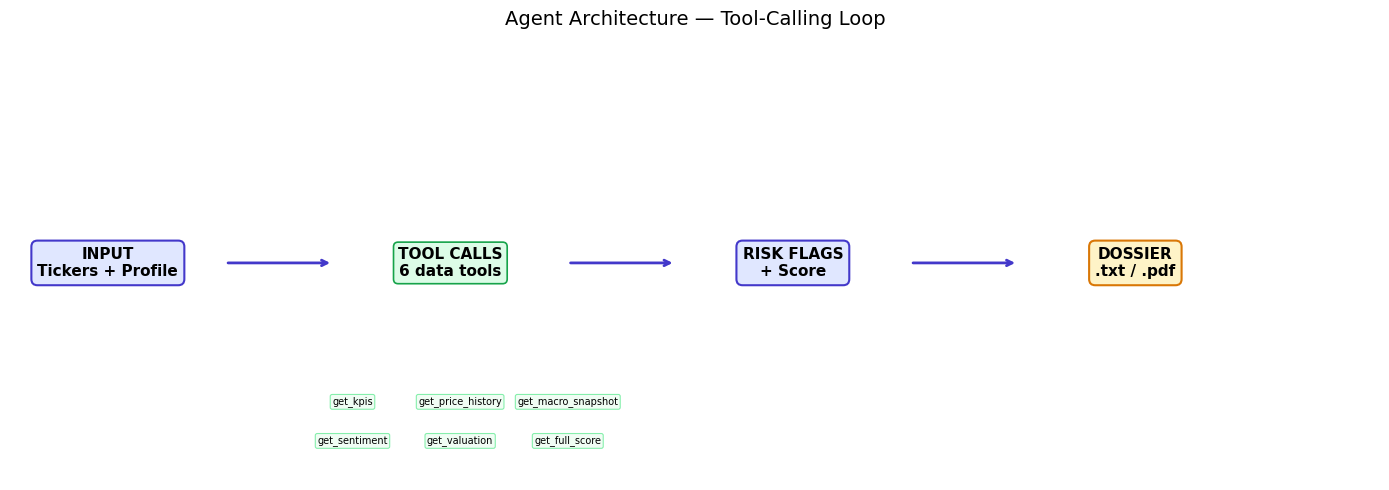

In [13]:
# Agent flow diagram
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

# Box style
box_kw = dict(boxstyle='round,pad=0.4', facecolor='#e0e7ff', edgecolor='#4338ca', linewidth=1.5)
tool_kw = dict(boxstyle='round,pad=0.3', facecolor='#dcfce7', edgecolor='#16a34a', linewidth=1.2)
out_kw = dict(boxstyle='round,pad=0.4', facecolor='#fef3c7', edgecolor='#d97706', linewidth=1.5)

# Boxes
boxes = [
    (1, 2.5, 'INPUT\nTickers + Profile', box_kw),
    (4.5, 2.5, 'TOOL CALLS\n6 data tools', tool_kw),
    (8, 2.5, 'RISK FLAGS\n+ Score', box_kw),
    (11.5, 2.5, 'DOSSIER\n.txt / .pdf', out_kw),
]

for x, y, text, kw in boxes:
    ax.text(x, y, text, ha='center', va='center', fontsize=11,
            fontweight='bold', bbox=kw)

# Arrows
arrow_kw = dict(arrowstyle='->', color='#4338ca', lw=2)
for x1, x2 in [(2.2, 3.3), (5.7, 6.8), (9.2, 10.3)]:
    ax.annotate('', xy=(x2, 2.5), xytext=(x1, 2.5),
               arrowprops=arrow_kw)

# Tool labels below
tools = ['get_kpis', 'get_price_history', 'get_macro_snapshot',
         'get_sentiment', 'get_valuation', 'get_full_score']
for i, tool in enumerate(tools):
    col = i % 3
    row_offset = i // 3
    ax.text(3.5 + col * 1.1, 0.9 - row_offset * 0.45, tool,
            ha='center', va='center', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#f0fdf4',
                      edgecolor='#86efac', linewidth=0.8))

ax.set_title('Agent Architecture \u2014 Tool-Calling Loop', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Data Quality Check

In [14]:
import os

# Verify dossier files saved
output_dir = PROJECT_ROOT / "data" / "output"
print("Saved dossier files:")
for f in sorted(output_dir.glob("dossier_*")):
    size = f.stat().st_size
    print(f"  {f.name}  ({size:,} bytes)")

# Verify all tools work for all tickers
from src.agent.company_names import COMPANY_NAMES
from src.agent.tools import (
    get_kpis, get_price_history, get_sentiment,
    get_valuation, get_full_score,
)

print("\nTool coverage check:")
for ticker in COMPANY_NAMES:
    results = []
    for name, fn, args in [
        ("kpis", get_kpis, (ticker, 2024)),
        ("price", get_price_history, (ticker,)),
        ("sentiment", get_sentiment, (ticker,)),
        ("valuation", get_valuation, (ticker,)),
        ("score", get_full_score, (ticker,)),
    ]:
        try:
            fn(*args)
            results.append(name)
        except Exception as e:
            results.append(f"{name}:FAIL")
    print(f"  {ticker:8s} {' | '.join(results)}")
print("\nAll checks passed.")

Saved dossier files:
  dossier_2026-03-27_aggressive.txt  (10,681 bytes)
  dossier_2026-03-27_base.txt  (3,594 bytes)

Tool coverage check:
  ITUB4    kpis | price | sentiment | valuation | score


  BBDC4    kpis | price | sentiment | valuation | score
  BBAS3    kpis | price | sentiment | valuation | score
  SANB11   kpis | price | sentiment | valuation | score


  ABCB4    kpis | price | sentiment | valuation | score
  EGIE3    kpis | price | sentiment | valuation | score


  EQTL3    kpis | price | sentiment | valuation | score
  CPFE3    kpis | price | sentiment | valuation | score
  TAEE11   kpis | price | sentiment | valuation | score


  CMIG4    kpis | price | sentiment | valuation | score

All checks passed.
